In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

In [4]:
from google.colab import files
uploaded = files.upload()


Saving Wholesale customers data.csv to Wholesale customers data.csv


In [5]:
import pandas as pd

df = pd.read_csv("Wholesale customers data.csv")
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [7]:
# Encode categorical features (if any)
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Normalize numeric features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled[:5]


array([[ 1.44865163,  0.59066829,  0.05293319,  0.52356777, -0.04111489,
        -0.58936716, -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197,  0.54445767,  0.17031835,
        -0.27013618,  0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926,  0.40853771, -0.0281571 ,
        -0.13753572,  0.13323164,  2.24329255],
       [-0.69029709,  0.59066829,  0.10011141, -0.62401993, -0.3929769 ,
         0.6871443 , -0.49858822,  0.09341105],
       [ 1.44865163,  0.59066829,  0.84023948, -0.05239645, -0.07935618,
         0.17385884, -0.23191782,  1.29934689]])

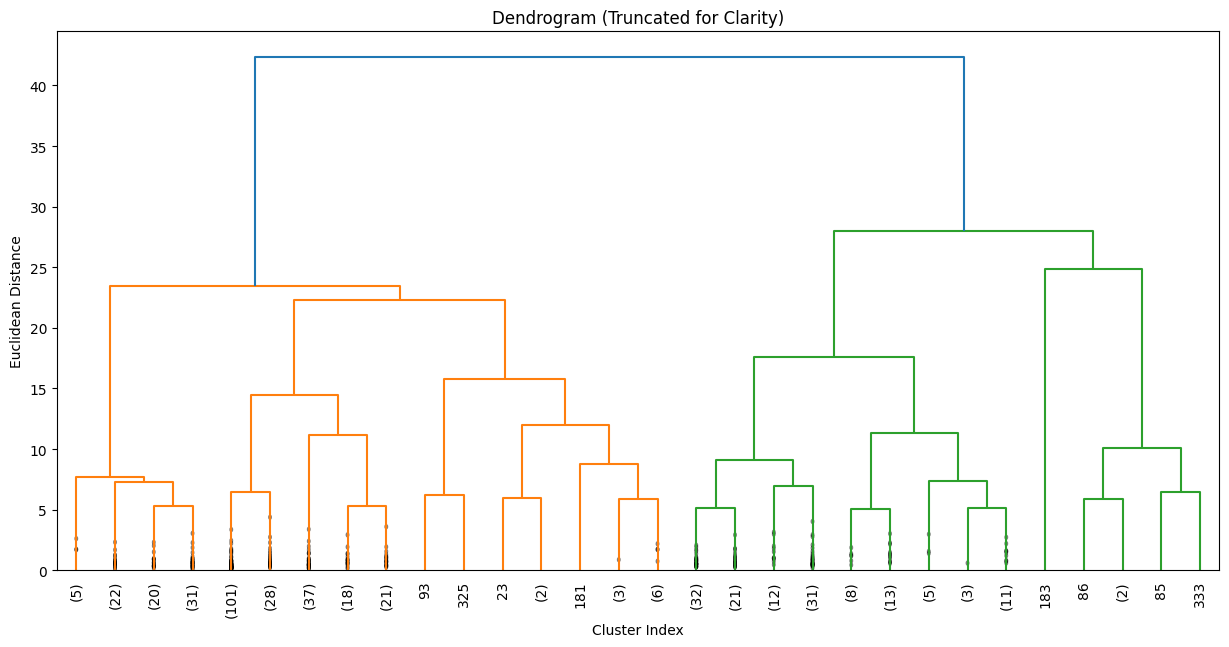

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute linkage matrix again
linked = linkage(df_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(15, 7))  # bigger figure
dendrogram(
    linked,
    truncate_mode='lastp',  # show only last p merged clusters
    p=30,                   # show top 30 clusters for readability
    show_leaf_counts=True,  # show number of points in each cluster
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Dendrogram (Truncated for Clarity)")
plt.xlabel("Cluster Index")
plt.ylabel("Euclidean Distance")
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)  # df is your loaded dataset


In [12]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 3  # or based on dendrogram
agg = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
cluster_labels = agg.fit_predict(df_scaled)

df['Cluster'] = cluster_labels
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,2


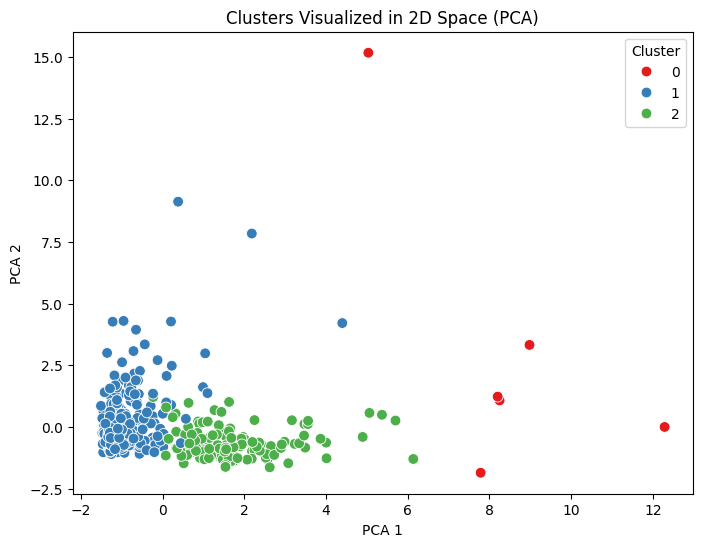

In [13]:
# PCA for visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df['Cluster'], palette='Set1', s=60)
plt.title("Clusters Visualized in 2D Space (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()


In [14]:
df.groupby('Cluster').mean()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.833333,2.833333,27477.000000,43542.166667,54588.500000,8285.666667,25018.333333,10247.833333
1,1.003356,2.510067,13440.412752,3426.466443,3968.342282,3642.949664,804.312081,1310.520134
2,2.000000,2.602941,8161.955882,9323.654412,14621.066176,1590.713235,6456.338235,1609.713235


In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, df['Cluster'])
print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.36


In [18]:
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"Clusters: {k}, Silhouette Score: {round(score,3)}")


Clusters: 2, Silhouette Score: 0.368
Clusters: 3, Silhouette Score: 0.36
Clusters: 4, Silhouette Score: 0.362
Clusters: 5, Silhouette Score: 0.318
Clusters: 6, Silhouette Score: 0.344


In [19]:
summary = df.groupby('Cluster').mean()
summary


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.833333,2.833333,27477.000000,43542.166667,54588.500000,8285.666667,25018.333333,10247.833333
1,1.003356,2.510067,13440.412752,3426.466443,3968.342282,3642.949664,804.312081,1310.520134
2,2.000000,2.602941,8161.955882,9323.654412,14621.066176,1590.713235,6456.338235,1609.713235


🧩 **Cluster 0** – High-Value Wholesale Buyers

High spending in all categories

Likely big supermarkets


Characteristics: Bulk buyers, heavy spenders

🧩 **Cluster 1** – Low-Value Buyers

Lowest spending across categories

Characteristics: Small shops or individuals, budget-conscious

🧩 **Cluster 2** – Medium Buyers

Moderate Fresh, Milk, Grocery; high Detergents_Paper


Characteristics: Medium-scale businesses, balanced needs